In [66]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder


In [67]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\Bike_price\used-bikes.csv")
df

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,TVS,82500
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,Royal Enfield,230000
2,Triumph Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph,1100000
3,TVS Apache RTR 180cc,65000,Bangalore,16329,First Owner,4,180,TVS,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha,150000
...,...,...,...,...,...,...,...,...,...
7307,Hero Hunk Rear Disc 150cc,25000,Delhi,48587,First Owner,8,150,Hero,120000
7308,Bajaj Avenger 220cc,35000,Bangalore,60000,First Owner,9,220,Bajaj,160000
7309,Harley-Davidson Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,Harley-Davidson,630000
7310,Bajaj Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,Bajaj,245000


In [68]:
df.head()

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,TVS,82500
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,Royal Enfield,230000
2,Triumph Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph,1100000
3,TVS Apache RTR 180cc,65000,Bangalore,16329,First Owner,4,180,TVS,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha,150000


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7312 entries, 0 to 7311
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   bike_name       7312 non-null   object
 1   price           7312 non-null   int64 
 2   city            7312 non-null   object
 3   kms_driven      7312 non-null   int64 
 4   owner           7312 non-null   object
 5   age             7312 non-null   int64 
 6   power           7312 non-null   int64 
 7   brand           7312 non-null   object
 8   Original Price  7312 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 514.3+ KB


In [70]:
df.describe()

,price,kms_driven,age,power,Original Price
count,7.312000e+03,7312.000000,7312.000000,7312.000000,7.312000e+03
mean,8.495145e+04,23949.871718,6.733862,228.496991,1.823393e+05
std,1.207519e+05,27340.904392,3.857574,158.035118,1.835454e+05
min,4.400000e+03,1.000000,1.000000,100.000000,5.000000e+04
25%,3.000000e+04,10148.500000,4.000000,125.000000,9.000000e+04
50%,5.500000e+04,19000.000000,6.000000,160.000000,1.500000e+05
75%,1.000000e+05,30396.750000,8.000000,350.000000,2.150000e+05
max,1.900000e+06,750000.000000,63.000000,1800.000000,2.750000e+06


In [71]:
df['brand'].unique()

array(['TVS', 'Royal Enfield', 'Triumph', 'Yamaha', 'Hero', 'Bajaj',
       'Suzuki', 'Benelli', 'Honda', 'KTM', 'Mahindra', 'Kawasaki',
       'Ducati', 'Hyosung', 'Harley-Davidson', 'Jawa', 'BMW', 'Indian',
       'Rajdoot', 'LML', 'Yezdi', 'MV', 'Ideal'], dtype=object)

In [72]:
pd.get_dummies(df['bike_name'],dtype=int,drop_first=True)

,BMW G 310 GS,BMW G 310 R,BMW S 1000 RR Pro,BMW S 1000 XR Pro,Bajaj Avenger 150cc,Bajaj Avenger 180cc,Bajaj Avenger 200cc,Bajaj Avenger 220cc,Bajaj Avenger Cruise 220,Bajaj Avenger Cruise 220 ABS,...,Yamaha YZF R6 600cc,Yamaha YZF-R1 1000cc,Yamaha YZF-R15 150cc,Yamaha YZF-R15 2.0 150cc,Yamaha YZF-R15 S 150cc,Yamaha YZF-R15 V3 150cc,Yamaha YZF-R1M 1000cc,Yamaha YZF-R3 320cc,Yamaha YZF-R3 320cc ABS,Yezdi Classic 250cc
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7307,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7308,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7309,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7310,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [73]:
# strip ka ise bike name ko hatana ka liya use karta ha 
df['brand']=df['brand'].str.lower().str.strip()

In [74]:
df

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,tvs,82500
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,royal enfield,230000
2,Triumph Daytona 675R,600000,Delhi,110,First Owner,8,675,triumph,1100000
3,TVS Apache RTR 180cc,65000,Bangalore,16329,First Owner,4,180,tvs,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,yamaha,150000
...,...,...,...,...,...,...,...,...,...
7307,Hero Hunk Rear Disc 150cc,25000,Delhi,48587,First Owner,8,150,hero,120000
7308,Bajaj Avenger 220cc,35000,Bangalore,60000,First Owner,9,220,bajaj,160000
7309,Harley-Davidson Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,harley-davidson,630000
7310,Bajaj Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,bajaj,245000


In [75]:
df['city'].unique()

array(['Ahmedabad', 'Delhi', 'Bangalore', 'Mumbai', 'Kalyan', 'Faridabad',
       'Mettur', 'Hyderabad', 'Kaithal', 'Gurgaon', 'Pune', 'Noida',
       'Nashik', 'Kochi', 'Allahabad', 'Samastipur', 'Nadiad', 'Lucknow',
       'Jaipur', 'Karnal', 'Gorakhpur', 'Vidisha', 'Hosur', 'Bagalkot',
       'Baripara', 'Agra', 'Dharwad', 'Vadodara', 'Jalandhar', 'Surat',
       'Chennai', 'Navi Mumbai', 'Gandhidham', 'Visakhapatnam',
       'Thrissur', 'Kolkata', 'Ernakulam', 'Barasat', 'Ghaziabad',
       'Bhubaneshwar', 'Amritsar', 'Bhopal', 'Hamirpur(hp)', 'Kottayam',
       'Arrah', 'Patiala', 'Ranga Reddy', 'Mandi', 'Ludhiana', 'Mandya',
       'Siliguri', 'Aurangabad', 'Kanpur', 'Bhilwara', 'Meerut', 'Rewari',
       'Ahmednagar', 'Wardha', 'Chandigarh', 'Ranchi', 'Panvel', 'Thane',
       'Jabalpur', 'Kota', 'Rohtak', 'Rajkot', 'Varanasi', '24 Pargana',
       'Banka', 'Nagpur', 'Banki', 'Pali', 'Chhatarpur', 'Katihar',
       'Mohali', 'Rudrapur', 'Coimbatore', 'Jajpur', 'Mysore', 'Adoni',

In [76]:
df['city']=df['city'].str.lower().str.strip()

In [77]:
df

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,ahmedabad,17654,First Owner,3,110,tvs,82500
1,Royal Enfield Classic 350cc,119900,delhi,11000,First Owner,4,350,royal enfield,230000
2,Triumph Daytona 675R,600000,delhi,110,First Owner,8,675,triumph,1100000
3,TVS Apache RTR 180cc,65000,bangalore,16329,First Owner,4,180,tvs,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,bangalore,10000,First Owner,3,150,yamaha,150000
...,...,...,...,...,...,...,...,...,...
7307,Hero Hunk Rear Disc 150cc,25000,delhi,48587,First Owner,8,150,hero,120000
7308,Bajaj Avenger 220cc,35000,bangalore,60000,First Owner,9,220,bajaj,160000
7309,Harley-Davidson Street 750 ABS,450000,jodhpur,3430,First Owner,4,750,harley-davidson,630000
7310,Bajaj Dominar 400 ABS,139000,hyderabad,21300,First Owner,4,400,bajaj,245000


In [78]:
df.isnull().sum()

bike_name         0
price             0
city              0
kms_driven        0
owner             0
age               0
power             0
brand             0
Original Price    0
dtype: int64

In [79]:
df.drop(['bike_name'],axis=1,inplace=True)

In [80]:
df

,price,city,kms_driven,owner,age,power,brand,Original Price
0,35000,ahmedabad,17654,First Owner,3,110,tvs,82500
1,119900,delhi,11000,First Owner,4,350,royal enfield,230000
2,600000,delhi,110,First Owner,8,675,triumph,1100000
3,65000,bangalore,16329,First Owner,4,180,tvs,140000
4,80000,bangalore,10000,First Owner,3,150,yamaha,150000
...,...,...,...,...,...,...,...,...
7307,25000,delhi,48587,First Owner,8,150,hero,120000
7308,35000,bangalore,60000,First Owner,9,220,bajaj,160000
7309,450000,jodhpur,3430,First Owner,4,750,harley-davidson,630000
7310,139000,hyderabad,21300,First Owner,4,400,bajaj,245000


In [81]:
df.duplicated().sum()

np.int64(1)

In [82]:
# df.drop_duplicates(inplace=True)

In [83]:
df.duplicated().sum()

np.int64(1)

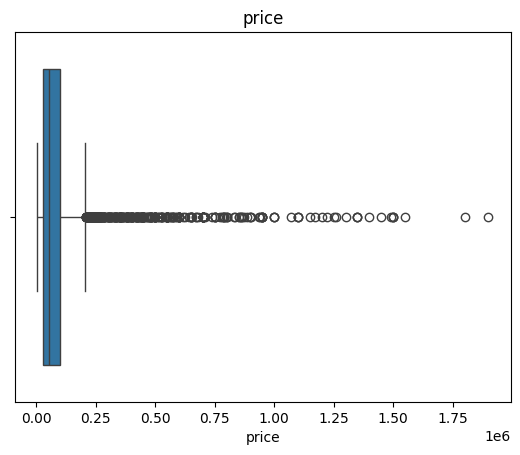

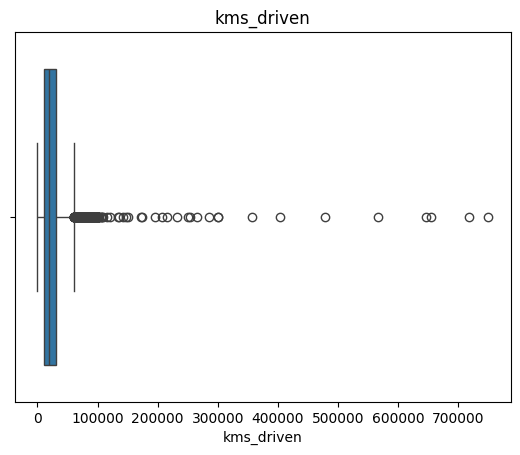

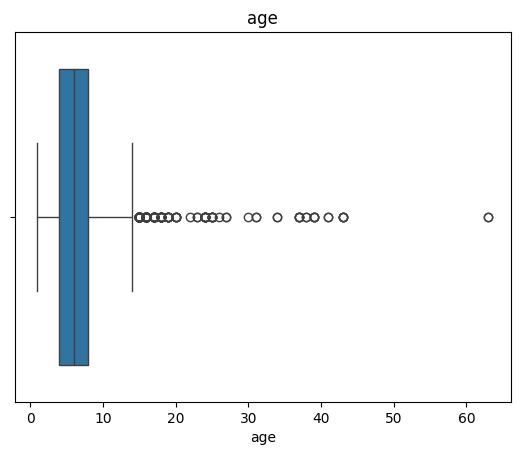

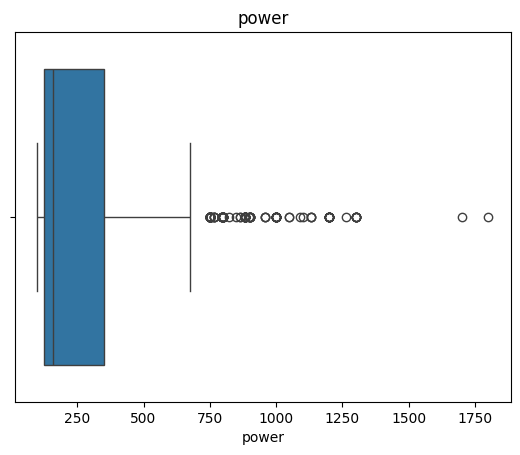

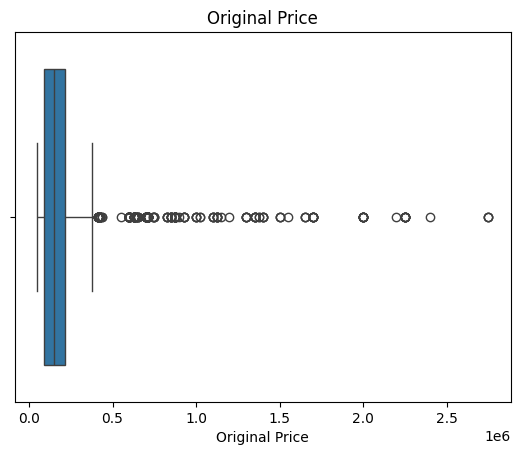

In [84]:
for col in df.select_dtypes(include=[np.number]).columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [85]:
df

,price,city,kms_driven,owner,age,power,brand,Original Price
0,35000,ahmedabad,17654,First Owner,3,110,tvs,82500
1,119900,delhi,11000,First Owner,4,350,royal enfield,230000
2,600000,delhi,110,First Owner,8,675,triumph,1100000
3,65000,bangalore,16329,First Owner,4,180,tvs,140000
4,80000,bangalore,10000,First Owner,3,150,yamaha,150000
...,...,...,...,...,...,...,...,...
7307,25000,delhi,48587,First Owner,8,150,hero,120000
7308,35000,bangalore,60000,First Owner,9,220,bajaj,160000
7309,450000,jodhpur,3430,First Owner,4,750,harley-davidson,630000
7310,139000,hyderabad,21300,First Owner,4,400,bajaj,245000


In [86]:
df_num=df.select_dtypes(include=[np.number])
df_num

,price,kms_driven,age,power,Original Price
0,35000,17654,3,110,82500
1,119900,11000,4,350,230000
2,600000,110,8,675,1100000
3,65000,16329,4,180,140000
4,80000,10000,3,150,150000
...,...,...,...,...,...
7307,25000,48587,8,150,120000
7308,35000,60000,9,220,160000
7309,450000,3430,4,750,630000
7310,139000,21300,4,400,245000


In [87]:
from sklearn.impute import KNNImputer
q1=df_num.quantile(0.25)
q3=df_num.quantile(0.75)

iqr =q3-q1
lower=q1-1.5*iqr
upper =q3+1.5*iqr
df_num[(df_num<=lower) | (df_num>=upper)]=np.nan



In [88]:
df_num.isnull().sum()

price             349
kms_driven        334
age               332
power             168
Original Price    256
dtype: int64

In [89]:
imputer=KNNImputer(n_neighbors=3)
df_clean=pd.DataFrame(imputer.fit_transform(df_num),columns=df_num.columns)

In [90]:
df_clean

,price,kms_driven,age,power,Original Price
0,35000.000000,17654.0,3.0,110.0,82500.000000
1,119900.000000,11000.0,4.0,350.0,230000.000000
2,140000.000000,110.0,8.0,675.0,296666.666667
3,65000.000000,16329.0,4.0,180.0,140000.000000
4,80000.000000,10000.0,3.0,150.0,150000.000000
...,...,...,...,...,...
7307,25000.000000,48587.0,8.0,150.0,120000.000000
7308,35000.000000,60000.0,9.0,220.0,160000.000000
7309,72666.666667,3430.0,4.0,150.0,130000.000000
7310,139000.000000,21300.0,4.0,400.0,245000.000000


In [91]:
df_clean.isnull().sum()

price             0
kms_driven        0
age               0
power             0
Original Price    0
dtype: int64

In [92]:
# pair plot
df_clean.columns 


Index(['price', 'kms_driven', 'age', 'power', 'Original Price'], dtype='object')

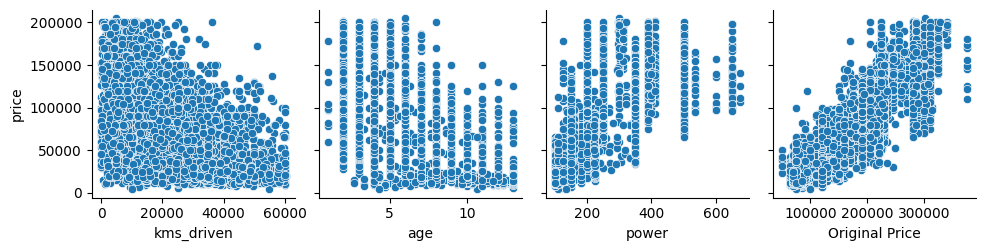

In [93]:
sns.pairplot(df_clean,x_vars=['kms_driven','age','power','Original Price'],y_vars=['price'])

In [94]:
df_clean['price'].corr(df['Original Price'])

np.float64(0.3536181117315999)

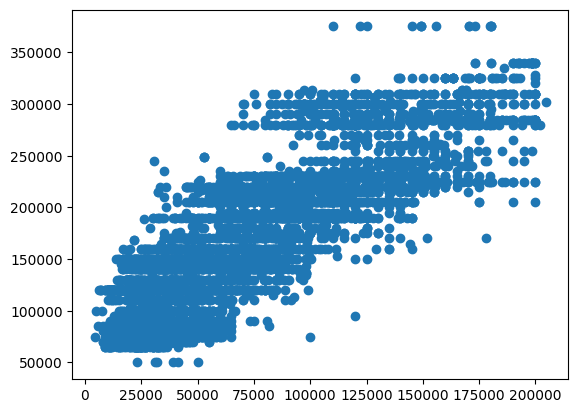

In [95]:
plt.scatter(df_clean['price'], df_clean['Original Price'])

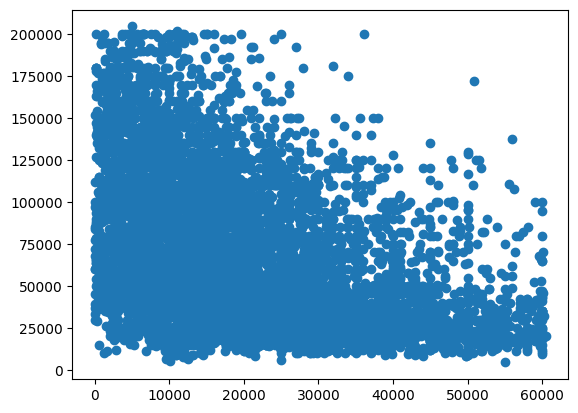

In [96]:
plt.scatter(df_clean['kms_driven'],df_clean['price'])

In [97]:
df

,price,city,kms_driven,owner,age,power,brand,Original Price
0,35000,ahmedabad,17654,First Owner,3,110,tvs,82500
1,119900,delhi,11000,First Owner,4,350,royal enfield,230000
2,600000,delhi,110,First Owner,8,675,triumph,1100000
3,65000,bangalore,16329,First Owner,4,180,tvs,140000
4,80000,bangalore,10000,First Owner,3,150,yamaha,150000
...,...,...,...,...,...,...,...,...
7307,25000,delhi,48587,First Owner,8,150,hero,120000
7308,35000,bangalore,60000,First Owner,9,220,bajaj,160000
7309,450000,jodhpur,3430,First Owner,4,750,harley-davidson,630000
7310,139000,hyderabad,21300,First Owner,4,400,bajaj,245000


In [98]:
df_clean

,price,kms_driven,age,power,Original Price
0,35000.000000,17654.0,3.0,110.0,82500.000000
1,119900.000000,11000.0,4.0,350.0,230000.000000
2,140000.000000,110.0,8.0,675.0,296666.666667
3,65000.000000,16329.0,4.0,180.0,140000.000000
4,80000.000000,10000.0,3.0,150.0,150000.000000
...,...,...,...,...,...
7307,25000.000000,48587.0,8.0,150.0,120000.000000
7308,35000.000000,60000.0,9.0,220.0,160000.000000
7309,72666.666667,3430.0,4.0,150.0,130000.000000
7310,139000.000000,21300.0,4.0,400.0,245000.000000


In [99]:
df.drop(['price', 'kms_driven', 'age', 'power', 'Original Price'],inplace=True,axis=1)

In [100]:
ori_df=pd.concat([df,df_clean],axis=1)

In [101]:
ori_df.isnull().sum()

city              0
owner             0
brand             0
price             0
kms_driven        0
age               0
power             0
Original Price    0
dtype: int64

In [102]:
ori_df

,city,owner,brand,price,kms_driven,age,power,Original Price
0,ahmedabad,First Owner,tvs,35000.000000,17654.0,3.0,110.0,82500.000000
1,delhi,First Owner,royal enfield,119900.000000,11000.0,4.0,350.0,230000.000000
2,delhi,First Owner,triumph,140000.000000,110.0,8.0,675.0,296666.666667
3,bangalore,First Owner,tvs,65000.000000,16329.0,4.0,180.0,140000.000000
4,bangalore,First Owner,yamaha,80000.000000,10000.0,3.0,150.0,150000.000000
...,...,...,...,...,...,...,...,...
7307,delhi,First Owner,hero,25000.000000,48587.0,8.0,150.0,120000.000000
7308,bangalore,First Owner,bajaj,35000.000000,60000.0,9.0,220.0,160000.000000
7309,jodhpur,First Owner,harley-davidson,72666.666667,3430.0,4.0,150.0,130000.000000
7310,hyderabad,First Owner,bajaj,139000.000000,21300.0,4.0,400.0,245000.000000


In [103]:
multi_df=ori_df.select_dtypes(include=[np.number]).drop('price',axis=1)

In [104]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df=pd.DataFrame()
vif_df['features']=multi_df.columns
vif_df['vif']=[variance_inflation_factor(multi_df.values,i) for i in range(multi_df.shape[1])]

In [105]:
vif_df

,features,vif
0,kms_driven,4.445898
1,age,5.960635
2,power,17.983823
3,Original Price,20.146973


In [106]:
# ori_df.drop('Original Price',axis=1,inplace=True)


<Axes: xlabel='brand'>

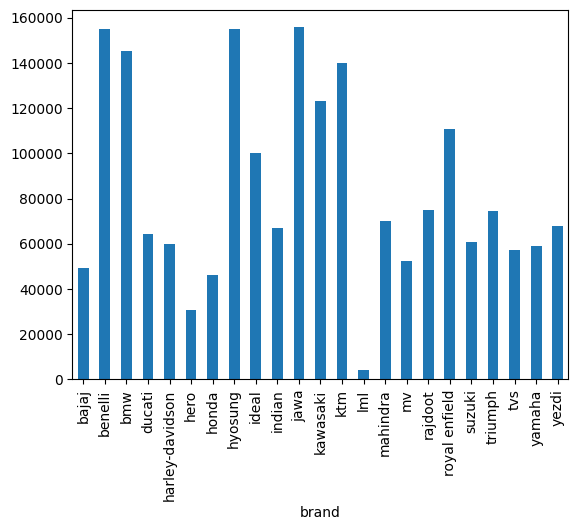

In [107]:
ori_df.groupby('brand')['price'].mean().plot(kind='bar')

In [108]:
ori_df['brand'].value_counts()

brand
bajaj              2031
royal enfield      1364
hero               1167
honda               672
yamaha              651
tvs                 481
ktm                 375
suzuki              203
harley-davidson      91
kawasaki             61
hyosung              53
mahindra             50
benelli              46
triumph              21
ducati               19
bmw                  10
jawa                  7
indian                3
mv                    3
rajdoot               1
lml                   1
yezdi                 1
ideal                 1
Name: count, dtype: int64

In [109]:
ori_df=ori_df[ori_df['brand'].map((ori_df['brand'].value_counts())>100)]

In [110]:
ori_df['owner'].value_counts()


owner
First Owner             6311
Second Owner             546
Third Owner               76
Fourth Owner Or More      11
Name: count, dtype: int64

In [111]:
ori_df

,city,owner,brand,price,kms_driven,age,power,Original Price
0,ahmedabad,First Owner,tvs,35000.0,17654.0,3.0,110.0,82500.0
1,delhi,First Owner,royal enfield,119900.0,11000.0,4.0,350.0,230000.0
3,bangalore,First Owner,tvs,65000.0,16329.0,4.0,180.0,140000.0
4,bangalore,First Owner,yamaha,80000.0,10000.0,3.0,150.0,150000.0
5,delhi,First Owner,yamaha,53499.0,25000.0,6.0,150.0,145000.0
...,...,...,...,...,...,...,...,...
7306,bangalore,First Owner,bajaj,50000.0,29134.0,7.0,220.0,160000.0
7307,delhi,First Owner,hero,25000.0,48587.0,8.0,150.0,120000.0
7308,bangalore,First Owner,bajaj,35000.0,60000.0,9.0,220.0,160000.0
7310,hyderabad,First Owner,bajaj,139000.0,21300.0,4.0,400.0,245000.0


In [112]:
# Categorical Encoding

le_owner=LabelEncoder()
ori_df['owner_encoder']=le_owner.fit_transform(ori_df['owner'])

le_brand=LabelEncoder()
ori_df['brand_encoder']=le_brand.fit_transform(ori_df['brand'])

le_city=LabelEncoder()
ori_df['city_encoder']=le_city.fit_transform(ori_df['city'])



C:\Users\HP\AppData\Local\Temp\ipykernel_11356\3408158946.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ori_df['owner_encoder']=le_owner.fit_transform(ori_df['owner'])
C:\Users\HP\AppData\Local\Temp\ipykernel_11356\3408158946.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ori_df['brand_encoder']=le_brand.fit_transform(ori_df['brand'])
C:\Users\HP\AppData\Local\Temp\ipykernel_11356\3408158946.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

In [113]:
ori_df

,city,owner,brand,price,kms_driven,age,power,Original Price,owner_encoder,brand_encoder,city_encoder
0,ahmedabad,First Owner,tvs,35000.0,17654.0,3.0,110.0,82500.0,0,6,6
1,delhi,First Owner,royal enfield,119900.0,11000.0,4.0,350.0,230000.0,0,4,111
3,bangalore,First Owner,tvs,65000.0,16329.0,4.0,180.0,140000.0,0,6,43
4,bangalore,First Owner,yamaha,80000.0,10000.0,3.0,150.0,150000.0,0,7,43
5,delhi,First Owner,yamaha,53499.0,25000.0,6.0,150.0,145000.0,0,7,111
...,...,...,...,...,...,...,...,...,...,...,...
7306,bangalore,First Owner,bajaj,50000.0,29134.0,7.0,220.0,160000.0,0,0,43
7307,delhi,First Owner,hero,25000.0,48587.0,8.0,150.0,120000.0,0,1,111
7308,bangalore,First Owner,bajaj,35000.0,60000.0,9.0,220.0,160000.0,0,0,43
7310,hyderabad,First Owner,bajaj,139000.0,21300.0,4.0,400.0,245000.0,0,0,175


In [114]:
ori_df.columns

Index(['city', 'owner', 'brand', 'price', 'kms_driven', 'age', 'power',
       'Original Price', 'owner_encoder', 'brand_encoder', 'city_encoder'],
      dtype='object')

In [115]:
x=ori_df[['kms_driven', 'age', 'power','owner_encoder', 'brand_encoder', 'city_encoder']]
y=ori_df['price']

In [116]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=22)


In [117]:
scaler =StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.transform(x_test)


In [118]:
import  statsmodels.api as sm

In [119]:
x

,kms_driven,age,power,owner_encoder,brand_encoder,city_encoder
0,17654.0,3.0,110.0,0,6,6
1,11000.0,4.0,350.0,0,4,111
3,16329.0,4.0,180.0,0,6,43
4,10000.0,3.0,150.0,0,7,43
5,25000.0,6.0,150.0,0,7,111
...,...,...,...,...,...,...
7306,29134.0,7.0,220.0,0,0,43
7307,48587.0,8.0,150.0,0,1,111
7308,60000.0,9.0,220.0,0,0,43
7310,21300.0,4.0,400.0,0,0,175


In [120]:
x_train=sm.add_constant(x_train_scaler)

In [121]:
x_test=sm.add_constant(x_test_scaler)

In [122]:
x_train

array([[ 1.        , -0.17916035, -0.12829748, ...,  4.55116916,
         0.20097621,  1.49587563],
       [ 1.        ,  2.1166872 ,  0.60505099, ..., -0.31008158,
        -1.06672573, -0.56848096],
       [ 1.        ,  0.85322854, -0.12829748, ..., -0.31008158,
         0.20097621,  1.01251409],
       ...,
       [ 1.        , -0.07372362, -0.49497171, ..., -0.31008158,
        -0.2215911 , -0.89072199],
       [ 1.        , -0.05813087,  0.60505099, ..., -0.31008158,
         1.46867815, -1.25324315],
       [ 1.        , -0.20759856, -0.49497171, ..., -0.31008158,
        -0.64415842, -0.35701029]])

In [123]:
model=sm.OLS(y_train,x_train).fit()

In [124]:
y_train.shape

(5555,)

In [125]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     3189.
Date:                Fri, 02 Jan 2026   Prob (F-statistic):               0.00
Time:                        00:37:28   Log-Likelihood:                -63034.
No. Observations:                5555   AIC:                         1.261e+05
Df Residuals:                    5548   BIC:                         1.261e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.496e+04    275.270    236.001      0.0

In [126]:
lr=LinearRegression()

In [127]:
lr.fit(x_train_scaler,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [128]:
y_pred=lr.predict(x_test_scaler)

In [129]:
r2_score(y_test,y_pred)

0.7628516612757439

In [130]:
import joblib
joblib.dump(lr,'used_bike_price_model.pkl')
joblib.dump(scaler,"scaler.pkl")
joblib.dump(le_brand,"brand_encoder.pkl")
joblib.dump(le_owner,"owner_encoder.pkl")
joblib.dump(le_city,"city_encoder.pkl")
print("Model and Encoder saved successully")

Model and Encoder saved successully
